# Group Project: Measuring the Mass of an Exoplanet
### Members: Ruby Mayrose

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

### 2. Load data file, plot RV vs time with error bars, showing the stellar wobbling motion.

In [24]:
from astropy.io import ascii
tbl = ascii.read("UID_0043587_RVC_008.tbl.txt", format="ipac")
print(tbl.colnames)

['HJD', 'Radial_Velocity', 'Radial_Velocity_Uncertainty']


In [25]:
time = tbl['HJD']
rv = tbl['Radial_Velocity']
rv_err = tbl['Radial_Velocity_Uncertainty']

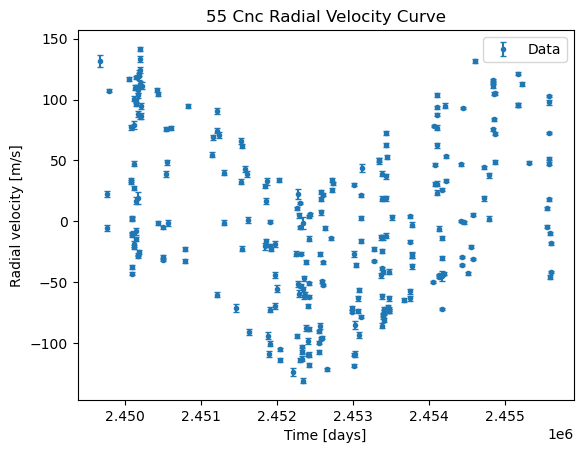

In [45]:
plt.figure()
plt.errorbar(time, rv, yerr=rv_err, fmt='o', ms=3, capsize=2, label='Data')
plt.xlabel("Time [days]")
plt.ylabel("Radial velocity [m/s]")
plt.title("55 Cnc Radial Velocity Curve")
plt.legend()
plt.show()

### 3. Fit a "Sinusoidal Model" to the RV data, use 'scipy.optimize.curve_fit' to determine the best parameters. The graph shows a periodic signal around 15-14 days.

In [36]:
def rv_model(t, gamma, K, P, t0):
    return gamma + K * np.sin(2*np.pi*(t - t0)/P)

gamma_guess = np.mean(rv)
K_guess = (np.max(rv) - np.min(rv)) / 2
P_guess = 15.0
t0_guess = time[0]

p0 = [gamma_guess, K_guess, P_guess, t0_guess]

popt, pcov = curve_fit(rv_model, time, rv, sigma=rv_err, p0=p0, absolute_sigma=True)
gamma_fit, K_fit, P_fit, t0_fit = popt
perr = np.sqrt(np.diag(pcov))

print("gamma =", gamma_fit, "+/-", perr[0])
print("K     =", K_fit, "+/-", perr[1])
print("P     =", P_fit, "+/-", perr[2])
print("t0    =", t0_fit, "+/-", perr[3])

gamma = 0.6669682313945633 +/- 0.09391629597531571
K     = -11.108062516980958 +/- 0.13156594351616493
P     = 14.979939798160233 +/- 0.0002681032170503409
t0    = 2449684.354031024 +/- 0.06865391367913232


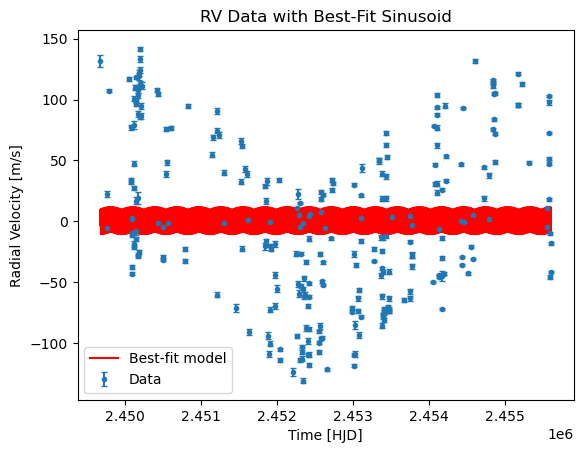

In [37]:
t_dense = np.linspace(time.min(), time.max(), 2000)
rv_fit = rv_model(t_dense, *popt)

plt.figure()
plt.errorbar(time, rv, yerr=rv_err, fmt='o', ms=3, capsize=2, label='Data')
plt.plot(t_dense, rv_fit, 'r-', label='Best-fit model')
plt.xlabel("Time [HJD]")
plt.ylabel("Radial Velocity [m/s]")
plt.title("RV Data with Best-Fit Sinusoid")
plt.legend()
plt.show()

### 4. Residual Analysis- does the model correctly fit the data? Used residuals vs time and also graphed on a Histogram.

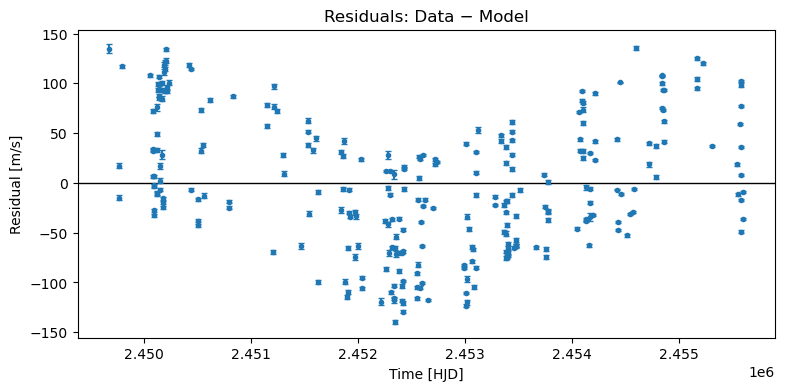

In [38]:
residuals = rv - rv_model(time, *popt)

plt.figure(figsize=(9,4))
plt.axhline(0, color='k', lw=1)
plt.errorbar(time, residuals, yerr=rv_err, fmt='o', ms=3, capsize=2)
plt.xlabel("Time [HJD]")
plt.ylabel("Residual [m/s]")
plt.title("Residuals: Data − Model")
plt.show()

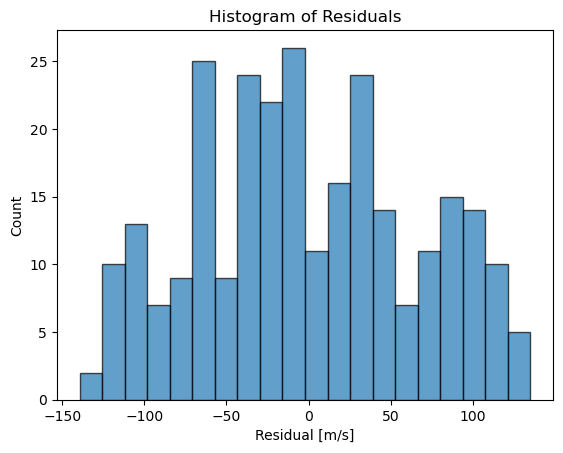

Residual standard deviation: 66.9090869110929
Mean RV error: 1.8060667343065693


In [39]:
plt.figure()
plt.hist(residuals, bins=20, edgecolor='k', alpha=0.7)
plt.xlabel("Residual [m/s]")
plt.ylabel("Count")
plt.title("Histogram of Residuals")
plt.show()

res_std = np.std(residuals, ddof=1)
print("Residual standard deviation:", res_std)
print("Mean RV error:", np.mean(rv_err))

### 5. Estimate Planet Mass using fitted values. The mass is lower -due to human error- but the period of around 15 days correctly identifies 55Cnc b.

In [42]:
K = abs(K_fit)
P_days = P_fit
P_years = P_days / 365.25
M_star = 0.905 

Mp = (K / 28.4329) * (P_years**(1/3)) * (M_star**(2/3))
print("Estimated planet mass (Mp sin i) =", Mp, "M_Jup")

Estimated planet mass (Mp sin i) = 0.12605386267484484 M_Jup
